In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mat
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
import category_encoders as ce
import xgboost as xgb

C:\Users\shive\AppData\Roaming\Python\Python37\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.9' currently installed).
  warnings.warn(msg, UserWarning)


In [2]:
# pip install pandas

# Reading Data

In [3]:
df= pd.read_csv("Craft Demo- Fraud Policy DataSet.csv")

In [4]:
df.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Phone_Type_Indicator,Owner_Service_Discontinued_Indicator,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud
0,1000001,550.0,81.0,2.167,5,6,2,-1,-2,-1,...,W,0.0,3.0,4.0,Cingular Wireless,AT&T,Wireless,NaN,N,0
1,1000002,539.0,98.0,1.730,2,6,1,1,-1,-1,...,L,0.0,3.0,5.0,Cbeyond,Birch Communications,Wireline,2.0,NaN,0
2,1000003,361.0,500.0,0.744,7,5,-1,2,2,0,...,W,0.0,3.0,4.0,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0
3,1000004,442.0,119.0,0.405,2,8,2,1,2,0,...,W,0.0,1.0,2.0,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0
4,1000005,431.0,82.0,1.063,1,8,2,1,2,2,...,W,0.0,2.0,3.0,T-Mobile US-TSI,T-Mobile,Wireless,NaN,N,0


In [5]:
df.shape

(21497, 23)

In [6]:
df["Identifier"].nunique()

21497

In [7]:
df["Fraud"].mean()

0.06963762385449132

In [8]:
df.dtypes

Identifier                                  int64
IdentityScore                             float64
EAScore                                   float64
UWScore                                   float64
Owner_Verified_Components                   int64
Owner_Negatively_Verified_Components        int64
Owner_Phone_1_to_Name_Linkage               int64
Owner_Phone_1_to_First_Name_Linkage         int64
Owner_Address_to_Phone_1_Linkage            int64
Owner_Email_to_Phone_1_Linkage              int64
Owner_Prepaid_Phone_Attribute              object
Owner_Business_Phone_Indicator             object
Owner_Phone_InService_Indicator            object
Owner_Phone_Type_Indicator                 object
Owner_Service_Discontinued_Indicator      float64
Owner_Recent_Phone_Usage_Past_2_months    float64
Owner_Phone_Usage_Past_12_months          float64
Owner_Phone_Carrier                        object
Owner_Parent_Phone_Carrier                 object
Owner_Technology_Indicator                 object


# EDA

In [9]:
mat.style.use("ggplot")
plt.rcParams["figure.figsize"] = (8,6)

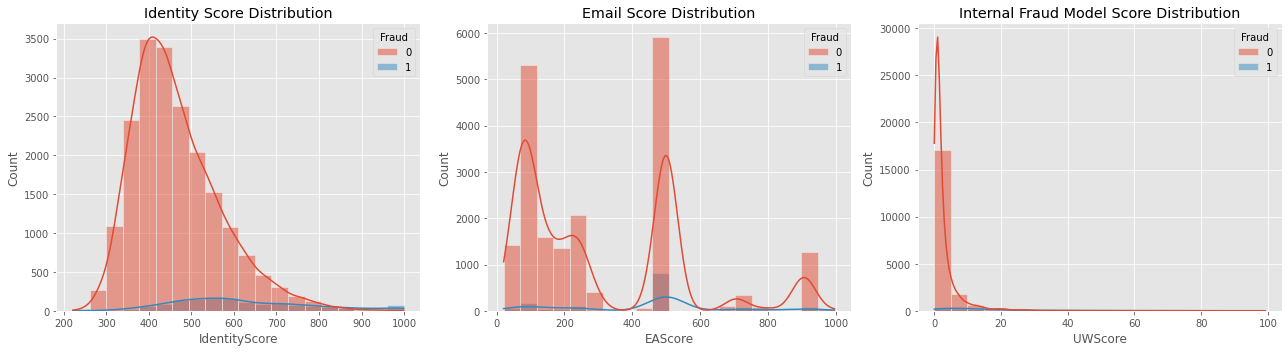

In [10]:
df_scores = df.dropna(subset=['IdentityScore', 'EAScore', 'UWScore'])

# Visualize distribution of internal scores by fraud label
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df_scores, x='IdentityScore', hue='Fraud', bins=20, kde=True, ax=axs[0])
axs[0].set_title('Identity Score Distribution')

sns.histplot(data=df_scores, x='EAScore', hue='Fraud', bins=20, kde=True, ax=axs[1])
axs[1].set_title('Email Score Distribution')

sns.histplot(data=df_scores, x='UWScore', hue='Fraud', bins=20, kde=True, ax=axs[2])
axs[2].set_title('Internal Fraud Model Score Distribution')

plt.tight_layout()
plt.show()

In [11]:
df.loc[df["IdentityScore"].isnull()].shape, df.loc[df["Fraud"].isnull()].shape

((3, 23), (0, 23))

In [12]:
df.loc[df["EAScore"].isnull()].shape, df.loc[df["UWScore"].isnull()].shape,

((50, 23), (0, 23))

In [13]:
df.loc[df["EAScore"].isnull()]["Fraud"].mean(), df.loc[df["IdentityScore"].isnull()]["Fraud"].mean()

(0.02, 0.0)

In [14]:
df.loc[df["IdentityScore"].isnull()].head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Phone_Type_Indicator,Owner_Service_Discontinued_Indicator,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud
4584,1004585,NaN,95.0,0.806,2,8,1,1,1,0,...,W,0.0,3.0,4.0,Sprint PCS,Sprint Nextel,Wireless,NaN,N,0
5435,1005436,NaN,236.0,1.096,5,2,2,-2,-1,0,...,W,0.0,3.0,4.0,Sprint PCS,Sprint Nextel,Wireless,NaN,N,0
8269,1008270,NaN,NaN,0.000,5,7,2,-2,-1,-2,...,W,0.0,2.0,3.0,Cingular Wireless,AT&T,Wireless,NaN,N,0


In [15]:
df["IdentityScore"].min(), df["IdentityScore"].max()

(222.0, 999.0)

In [16]:
df["EAScore"].min(), df["EAScore"].max()

(21.0, 995.0)

In [17]:
df["UWScore"].min(), df["UWScore"].max()

(0.0, 99.132)

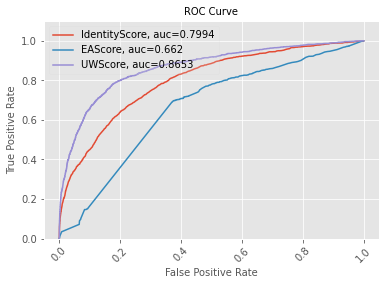

In [18]:
temp = df.loc[df["IdentityScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["IdentityScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["IdentityScore"]), 4)
plt.plot(fpr, tpr, label= "IdentityScore, auc={}".format(str(auc)))

temp = df.loc[df["EAScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["EAScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["EAScore"]), 4)
plt.plot(fpr, tpr, label= "EAScore, auc={}".format(str(auc)))

temp = df.loc[df["UWScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["UWScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["UWScore"]), 4)
plt.plot(fpr, tpr, label= "UWScore, auc={}".format(str(auc)))

plt.title("ROC Curve", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 1.1)
plt.xlabel("False Positive Rate", fontsize = 10)
plt.ylabel("True Positive Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

In [19]:
# def bin_of_scores(df, score, bins):
    
#     df = df.loc[df[score].notnull()]
#     df["cut_base_{}".format(score)] = pd.qcut(df[score], q= bins, precision = 6)
#     labels = [str(i) for i in range (1, df["cut_base_{}".format(score)].nunique() + 1, 1)]
#     df["bins_{}".format(score)] = pd.qcut(df[score], bins, labels = labels)

#     return df

In [20]:
#  df.loc[df[score].notnull(), score].head()

In [21]:
# def bin_of_scores(df, score, bins):
#     df = df.copy()
    
#     # Create column names
#     cut_col = f"cut_base_{score}"
#     bin_col = f"bins_{score}"

#     # Initialize bin column with 'Missing'
#     df[bin_col] = 'Missing'

#     # Only bin non-null values
#     non_null_mask = df[score].notnull()
#     non_null_scores = df.loc[non_null_mask, score]

#     # Handle duplicate edges gracefully
#     cut_result = pd.qcut(non_null_scores, q=bins, precision=6, duplicates='drop')
#     actual_bins = cut_result.unique()
    
#     # Create labels
#     labels = [str(i) for i in range(1, len(actual_bins) + 1)]

#     # Assign bins to non-null values
#     df.loc[non_null_mask, cut_col] = cut_result
#     df.loc[non_null_mask, bin_col] = pd.qcut(non_null_scores, q=bins, labels=labels, duplicates='drop')

#     return df

# # Example usage for multiple scores
# score_list = ["IdentityScore", "EAScore", "UWScore"]  # replace with your column names

# # Apply binning
# for score in score_list:
#     df = bin_of_scores(df, score, 10)

In [22]:
def bad_capture_rate(df, target, prediction, bins):

    df["cut_base"] = pd.qcut(df[prediction], q= bins, precision = 6, duplicates= "drop")

    results = df.groupby(["cut_base"]).agg({prediction: ["count"], target: ["sum"]}).reset_index()
    results.columns= ["cut_base_{}".format(prediction), 'base_total_count', 'base_bad_count']
    results["base_good_count"]= results["base_total_count"] - results["base_bad_count"] 

    results = results.sort_values(by= "cut_base_{}".format(prediction), ascending = False).reset_index().drop('index', axis=1)

    results["bad_rate"] = results["base_bad_count"]/results["base_total_count"]
    bad_total = results["base_bad_count"].sum()
    results["cumulative_total"] = results["base_total_count"].cumsum()
    results["cumulative_bad"] = results["base_bad_count"].cumsum()
    results["cumulative_precision"] = results["cumulative_bad"]/results["cumulative_total"]
    results["bad_capture_rate_bin"] = results["base_bad_count"]/bad_total
    results["bad_capture_rate_cumulative_bin"] = results["cumulative_bad"]/bad_total
    results["precentile"] = results["base_total_count"].cumsum()/results["base_total_count"].sum()

    return results

In [23]:
df_id = bad_capture_rate(df, "Fraud", "IdentityScore", 20)
df_ea = bad_capture_rate(df, "Fraud", "EAScore", 20)
df_uw = bad_capture_rate(df, "Fraud", "UWScore", 20)

In [24]:
df_id.head(10)

,cut_base_IdentityScore,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(700.0, 999.0]",1072,436,636,0.406716,1072,436,0.406716,0.291249,0.291249,0.049874
1,"(628.0, 700.0]",1074,165,909,0.153631,2146,601,0.280056,0.110220,0.401470,0.099842
2,"(590.0, 628.0]",1047,149,898,0.142311,3193,750,0.234889,0.099532,0.501002,0.148553
3,"(560.0, 590.0]",1081,138,943,0.127660,4274,888,0.207768,0.092184,0.593186,0.198846
4,"(537.0, 560.0]",1070,100,970,0.093458,5344,988,0.184880,0.066800,0.659987,0.248628
5,"(516.0, 537.0]",1093,77,1016,0.070448,6437,1065,0.165450,0.051436,0.711423,0.299479
6,"(497.0, 516.0]",1073,79,994,0.073625,7510,1144,0.152330,0.052772,0.764195,0.349400
7,"(481.0, 497.0]",1069,71,998,0.066417,8579,1215,0.141625,0.047428,0.811623,0.399135
8,"(466.0, 481.0]",1090,48,1042,0.044037,9669,1263,0.130624,0.032064,0.843687,0.449846
9,"(453.0, 466.0]",1043,45,998,0.043145,10712,1308,0.122106,0.030060,0.873747,0.498372


In [25]:
df_ea.head(10)

,cut_base_EAScore,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(904.0, 995.0]",206,51,155,0.247573,206,51,0.247573,0.034091,0.034091,0.009605
1,"(500.0, 904.0]",1875,175,1700,0.093333,2081,226,0.108602,0.116979,0.151070,0.097030
2,"(487.0, 500.0]",6492,818,5674,0.126001,8573,1044,0.121778,0.546791,0.697861,0.399730
3,"(248.0, 487.0]",989,35,954,0.035389,9562,1079,0.112843,0.023396,0.721257,0.445843
4,"(235.0, 248.0]",1144,71,1073,0.062063,10706,1150,0.107416,0.047460,0.768717,0.499184
5,"(204.0, 235.0]",1086,37,1049,0.034070,11792,1187,0.100661,0.024733,0.793449,0.549820
6,"(168.0, 204.0]",1052,35,1017,0.033270,12844,1222,0.095142,0.023396,0.816845,0.598872
7,"(137.0, 168.0]",1072,26,1046,0.024254,13916,1248,0.089681,0.017380,0.834225,0.648855
8,"(97.0, 137.0]",1015,33,982,0.032512,14931,1281,0.085795,0.022059,0.856283,0.696181
9,"(92.0, 97.0]",1002,29,973,0.028942,15933,1310,0.082219,0.019385,0.875668,0.742901


In [26]:
df_uw.head(10)

,cut_base_UWScore,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(16.2976, 99.132]",1075,564,511,0.524651,1075,564,0.524651,0.376754,0.376754,0.050007
1,"(9.1244, 16.2976]",1075,267,808,0.248372,2150,831,0.386512,0.178357,0.555110,0.100014
2,"(6.241, 9.1244]",1074,184,890,0.171322,3224,1015,0.314826,0.122912,0.678023,0.149974
3,"(4.637, 6.241]",1074,115,959,0.107076,4298,1130,0.262913,0.076820,0.754843,0.199935
4,"(3.615, 4.637]",1074,76,998,0.070764,5372,1206,0.224497,0.050768,0.805611,0.249895
5,"(2.921, 3.615]",1076,44,1032,0.040892,6448,1250,0.193859,0.029392,0.835003,0.299949
6,"(2.4194, 2.921]",1076,41,1035,0.038104,7524,1291,0.171584,0.027388,0.862391,0.350002
7,"(2.0386, 2.4194]",1075,32,1043,0.029767,8599,1323,0.153855,0.021376,0.883768,0.400009
8,"(1.726, 2.0386]",1074,17,1057,0.015829,9673,1340,0.138530,0.011356,0.895124,0.449970
9,"(1.485, 1.726]",1072,24,1048,0.022388,10745,1364,0.126943,0.016032,0.911156,0.499837


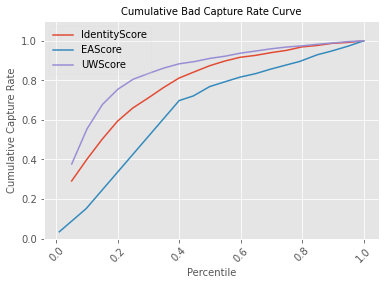

In [27]:
plt.plot(df_id["precentile"], df_id["bad_capture_rate_cumulative_bin"], label= "IdentityScore")
plt.plot(df_ea["precentile"], df_ea["bad_capture_rate_cumulative_bin"], label= "EAScore")
plt.plot(df_uw["precentile"], df_uw["bad_capture_rate_cumulative_bin"], label= "UWScore")

plt.title("Cumulative Bad Capture Rate Curve", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 1.1)
plt.xlabel("Percentile", fontsize = 10)
plt.ylabel("Cumulative Capture Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

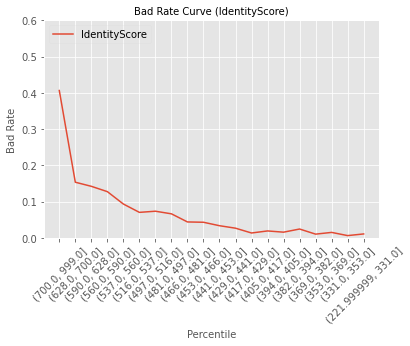

In [28]:
plt.plot(df_id["cut_base_IdentityScore"].astype(str), df_id["bad_rate"], label= "IdentityScore")
# plt.plot(df_ea["cut_base_EAScore"].astype(str), df_ea["bad_rate"], label= "EAScore")
# plt.plot(df_uw["cut_base_UWScore"].astype(str), df_uw["bad_rate"], label= "UWScore")

plt.title("Bad Rate Curve (IdentityScore)", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 0.6)
plt.xlabel("Percentile", fontsize = 10)
plt.ylabel("Bad Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

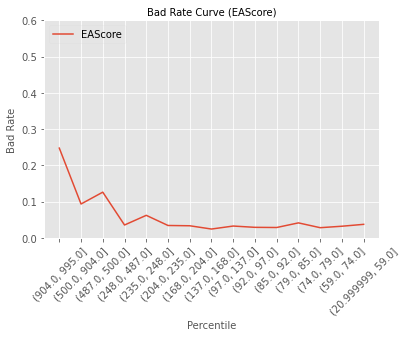

In [29]:
# plt.plot(df_id["cut_base_IdentityScore"].astype(str), df_id["bad_rate"], label= "IdentityScore")
plt.plot(df_ea["cut_base_EAScore"].astype(str), df_ea["bad_rate"], label= "EAScore")
# plt.plot(df_uw["cut_base_UWScore"].astype(str), df_uw["bad_rate"], label= "UWScore")

plt.title("Bad Rate Curve (EAScore)", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 0.6)
plt.xlabel("Percentile", fontsize = 10)
plt.ylabel("Bad Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

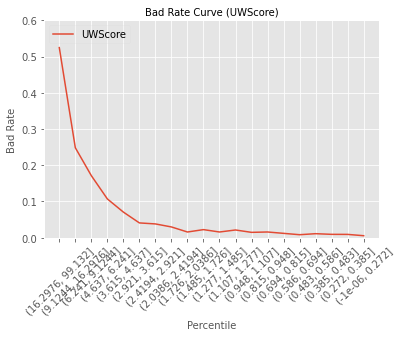

In [30]:
# plt.plot(df_id["cut_base_IdentityScore"].astype(str), df_id["bad_rate"], label= "IdentityScore")
# plt.plot(df_ea["cut_base_EAScore"].astype(str), df_ea["bad_rate"], label= "EAScore")
plt.plot(df_uw["cut_base_UWScore"].astype(str), df_uw["bad_rate"], label= "UWScore")

plt.title("Bad Rate Curve (UWScore)", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 0.6)
plt.xlabel("Percentile", fontsize = 10)
plt.ylabel("Bad Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

# Strategy

In [31]:
uw_th_approve = round(df["UWScore"].quantile(0.95))
id_th_approve = round(df["IdentityScore"].quantile(0.95))
ea_th_approve = round(df["EAScore"].quantile(0.9999))

In [32]:
uw_th_approve, id_th_approve

(16, 700)

In [33]:
uw_th_review = round(df["UWScore"].quantile(0.93))
id_th_review = round(df["IdentityScore"].quantile(0.93))
ea_th_review = round(df["EAScore"].quantile(0.99))

In [34]:
uw_th_approve, id_th_approve

(16, 700)

In [35]:
uw_th_review, id_th_review, ea_th_review

(12, 667, 904)

In [36]:
uw_th_review, id_th_review, ea_th_review

(12, 667, 904)

In [37]:
def base_strategy(row):
    if (
        row['UWScore'] >= uw_th_approve or
        row['IdentityScore'] >= id_th_approve
    ):
        return 'Decline'

    elif (
        (uw_th_review <= row["UWScore"] < uw_th_approve) or
        ((id_th_review <= row["IdentityScore"] < id_th_approve) if pd.notnull(row["IdentityScore"]) else True) or
        ((ea_th_review <= row["EAScore"]) if pd.notnull(row["EAScore"]) else True)
    ):
        return 'ManualReview'

    else:
        return 'Approve'

In [38]:
df['Decision'] = df.apply(base_strategy, axis=1)

In [39]:
df['Decision'].value_counts()

Approve         17979
ManualReview     1913
Decline          1605
Name: Decision, dtype: int64

In [40]:
df.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud,cut_base,Decision
0,1000001,550.0,81.0,2.167,5,6,2,-1,-2,-1,...,3.0,4.0,Cingular Wireless,AT&T,Wireless,NaN,N,0,"(2.0386, 2.4194]",Approve
1,1000002,539.0,98.0,1.730,2,6,1,1,-1,-1,...,3.0,5.0,Cbeyond,Birch Communications,Wireline,2.0,NaN,0,"(1.726, 2.0386]",Approve
2,1000003,361.0,500.0,0.744,7,5,-1,2,2,0,...,3.0,4.0,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.694, 0.815]",Approve
3,1000004,442.0,119.0,0.405,2,8,2,1,2,0,...,1.0,2.0,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.385, 0.483]",Approve
4,1000005,431.0,82.0,1.063,1,8,2,1,2,2,...,2.0,3.0,T-Mobile US-TSI,T-Mobile,Wireless,NaN,N,0,"(0.948, 1.107]",Approve


In [41]:
def strategy (df, decision):
    
    df_strategy= df.groupby(decision).agg({"Identifier": "count",
                            "Fraud": ["sum", "mean"]
                           }).reset_index()
    
    df_strategy.columns = ["Decision", "AppCount", "FraudCount", "FraudRate"]
    
    df_strategy["DecisionRate"] = df_strategy["AppCount"]/df_strategy["AppCount"].sum()
    df_strategy["FraudCaptureRate"] = df_strategy["FraudCount"]/df_strategy["FraudCount"].sum()
    
    return df_strategy

In [42]:
df_strategy= strategy(df, "Decision")

In [43]:
df_strategy

,Decision,AppCount,FraudCount,FraudRate,DecisionRate,FraudCaptureRate
0,Approve,17979,675,0.037544,0.836349,0.450902
1,Decline,1605,630,0.392523,0.074662,0.420842
2,ManualReview,1913,192,0.100366,0.088989,0.128257


# Simulation

## Without Internal Strategy

In [44]:
apps = df.shape[0]

In [45]:
df.loc[df["Fraud"]==1].shape[0]

1497

In [46]:
in_fraud_apps = df.loc[df["Fraud"]==1].shape[0]
in_fraud_loss = in_fraud_apps*500

In [47]:
in_fraud_loss

748500

In [48]:
in_legit_approved_apps = df.loc[df["Fraud"]==0].shape[0]
in_revenue = in_legit_approved_apps*40*12

In [49]:
in_revenue, in_fraud_loss

(9600000, 748500)

In [50]:
in_net_gain = in_revenue - in_fraud_loss
in_ROI = round(in_net_gain/in_fraud_loss,2)

In [51]:
in_ROI, in_net_gain

(11.83, 8851500)

## With Internal Strategy

In [52]:
df_strategy

,Decision,AppCount,FraudCount,FraudRate,DecisionRate,FraudCaptureRate
0,Approve,17979,675,0.037544,0.836349,0.450902
1,Decline,1605,630,0.392523,0.074662,0.420842
2,ManualReview,1913,192,0.100366,0.088989,0.128257


In [53]:
186/1881

0.09888357256778309

In [54]:
def ROI_calc (df_strategy, decision, vendor):
    
    # Approved segment
    total_apps = df_strategy["AppCount"].sum()
    
    approved_apps= df_strategy.loc[df_strategy["Decision"]== "Approve"]["AppCount"].values[0]
    fraud_app_approved = df_strategy.loc[df_strategy["Decision"]== "Approve"]["FraudCount"].values[0]
    legit_approved_apps = approved_apps - fraud_app_approved
    revenue_approved = legit_approved_apps*40*12
    fraud_loss_approved = fraud_app_approved*500
    
    # manual review segment
    mr_apps = df_strategy.loc[df_strategy["Decision"]== "ManualReview"]["AppCount"].values[0]
    fraud_app_mr = df_strategy.loc[df_strategy["Decision"]== "ManualReview"]["FraudCount"].values[0]
    legit_mr_apps = mr_apps - fraud_app_mr
    legit_mr_approved_apps = round(legit_mr_apps*0.3) #(assumption MR reviews declined all fraud apps)
    avoided_fraud_loss_mr = fraud_app_mr*500
    lost_legit_revenue_mr = (legit_mr_apps - legit_mr_approved_apps)*40*12
    revenue_mr_approved = legit_mr_approved_apps*40*12
    mr_cost = mr_apps*50
    
    # declined segment
    
    declined_apps = df_strategy.loc[df_strategy["Decision"]== "Decline"]["AppCount"].values[0]
    fraud_app_decline = df_strategy.loc[df_strategy["Decision"]== "Decline"]["FraudCount"].values[0]
    false_positives_decline = declined_apps - fraud_app_decline
    avoided_fraud_loss_decline = fraud_app_decline*500
    lost_legit_revenue_decline = false_positives_decline*40*12
    
    final_approved_apps= (approved_apps + legit_mr_approved_apps)
    final_approval_rate = final_approved_apps/total_apps
    fraud_rate  = fraud_app_approved/(approved_apps + legit_mr_approved_apps)                         
    
    if vendor == "Yes":
        vendor_call_cost = round((df_strategy["AppCount"].sum()*0.5), 4)
        
    if vendor == "No":
        vendor_call_cost = 0
        
    # lost/avoided costs
    total_avoided_fraud_loss = avoided_fraud_loss_mr + avoided_fraud_loss_decline
    total_lost_legit_revenue = lost_legit_revenue_mr + lost_legit_revenue_decline
    
    # ROI calculation
    total_revenue = revenue_approved + revenue_mr_approved
    total_cost = fraud_loss_approved + mr_cost + vendor_call_cost
    
    net_gain = total_revenue - total_cost
    ROI = round(net_gain/total_cost,2)
    
    # output data in df format
    out_dict= {}
    out_dict["TotalApps"] = total_apps
    out_dict["ApprovedApps"] = approved_apps
    out_dict["FraudAppsApproved"] = fraud_app_approved
    out_dict["LegitApprovedApps"] = legit_approved_apps
    out_dict["RevenurApprovedApps"] = revenue_approved
    out_dict["FraudLossApprovedApps"] = fraud_loss_approved
    
    out_dict["ManualReviewApps"] = mr_apps
    out_dict["FraudAppsManualReview"] = fraud_app_mr
    out_dict["LegitManualReviewApps"] = legit_mr_apps
    out_dict["LegitManualReviewApprovedApps"] = legit_mr_approved_apps
    out_dict["AvoidedFraudLossManualReview"] = avoided_fraud_loss_mr
    out_dict["LostLegitRevenuwManualReview"] = lost_legit_revenue_mr
    out_dict["RevenueApprovedAppsManualReview"] = revenue_mr_approved
    out_dict["ManualReviewCost"] = mr_cost
    
    out_dict["DeclinedApps"] = declined_apps
    out_dict["FraudAppsDecline"] = fraud_app_decline
    out_dict["FalsePositivesDecline"] = false_positives_decline
    out_dict["AvoidedFraudLossDecline"] = avoided_fraud_loss_decline
    out_dict["LostLegitRevenueDecline"] = lost_legit_revenue_decline
    
    out_dict["FinalApprovedApps"] = final_approved_apps
    out_dict["FinalApprovalRate"] = final_approval_rate
    out_dict["FraudRateBookedPortfolio"] = fraud_rate
    
    out_dict["VendorCallCost"] = vendor_call_cost
    out_dict["TotalAvoidedFraudLoss"] = total_avoided_fraud_loss
    out_dict["TotalLostLegitRevenue"] = total_lost_legit_revenue
    out_dict["TotalRevenue"] = total_revenue
    out_dict["TotalCost"] = total_cost
    out_dict["NetGain"] = net_gain
    out_dict["ROI"] = ROI
    
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    df = pd.DataFrame.from_dict(out_dict, orient='index', columns=['Value']).reset_index()
    df.columns = ['Metrics', 'Value']
    
    return df

In [55]:
out = ROI_calc (df_strategy, "Decision", vendor= "No")

In [56]:
out

,Metrics,Value
0,TotalApps,21497.0000
1,ApprovedApps,17979.0000
2,FraudAppsApproved,675.0000
3,LegitApprovedApps,17304.0000
4,RevenurApprovedApps,8305920.0000
5,FraudLossApprovedApps,337500.0000
6,ManualReviewApps,1913.0000
7,FraudAppsManualReview,192.0000
8,LegitManualReviewApps,1721.0000
9,LegitManualReviewApprovedApps,516.0000


## With Vendor Data

In [57]:
df.dtypes

Identifier                                   int64
IdentityScore                              float64
EAScore                                    float64
UWScore                                    float64
Owner_Verified_Components                    int64
Owner_Negatively_Verified_Components         int64
Owner_Phone_1_to_Name_Linkage                int64
Owner_Phone_1_to_First_Name_Linkage          int64
Owner_Address_to_Phone_1_Linkage             int64
Owner_Email_to_Phone_1_Linkage               int64
Owner_Prepaid_Phone_Attribute               object
Owner_Business_Phone_Indicator              object
Owner_Phone_InService_Indicator             object
Owner_Phone_Type_Indicator                  object
Owner_Service_Discontinued_Indicator       float64
Owner_Recent_Phone_Usage_Past_2_months     float64
Owner_Phone_Usage_Past_12_months           float64
Owner_Phone_Carrier                         object
Owner_Parent_Phone_Carrier                  object
Owner_Technology_Indicator     

In [58]:
extra_cols = ['Identifier', 'IdentityScore', 'EAScore', 'UWScore', 'Fraud', 'cut_base', 'Decision']
vendor_features= list(set(list(df.columns)) - set(extra_cols))

In [59]:
vendor_features

['Owner_Phone_1_to_Name_Linkage',
 'Owner_VoIP_Indicator',
 'Owner_Negatively_Verified_Components',
 'Owner_Service_Discontinued_Indicator',
 'Owner_Business_Phone_Indicator',
 'Owner_Phone_Carrier',
 'Owner_MVNO_Indicator',
 'Owner_Recent_Phone_Usage_Past_2_months',
 'Owner_Phone_Type_Indicator',
 'Owner_Verified_Components',
 'Owner_Technology_Indicator',
 'Owner_Phone_Usage_Past_12_months',
 'Owner_Parent_Phone_Carrier',
 'Owner_Prepaid_Phone_Attribute',
 'Owner_Address_to_Phone_1_Linkage',
 'Owner_Phone_InService_Indicator',
 'Owner_Email_to_Phone_1_Linkage',
 'Owner_Phone_1_to_First_Name_Linkage']

In [60]:
df.shape, len(vendor_features), len(extra_cols)

((21497, 25), 18, 7)

In [61]:
df[vendor_features].dtypes

Owner_Phone_1_to_Name_Linkage               int64
Owner_VoIP_Indicator                      float64
Owner_Negatively_Verified_Components        int64
Owner_Service_Discontinued_Indicator      float64
Owner_Business_Phone_Indicator             object
Owner_Phone_Carrier                        object
Owner_MVNO_Indicator                       object
Owner_Recent_Phone_Usage_Past_2_months    float64
Owner_Phone_Type_Indicator                 object
Owner_Verified_Components                   int64
Owner_Technology_Indicator                 object
Owner_Phone_Usage_Past_12_months          float64
Owner_Parent_Phone_Carrier                 object
Owner_Prepaid_Phone_Attribute              object
Owner_Address_to_Phone_1_Linkage            int64
Owner_Phone_InService_Indicator            object
Owner_Email_to_Phone_1_Linkage              int64
Owner_Phone_1_to_First_Name_Linkage         int64
dtype: object

In [62]:
df_vendor = df.copy()

In [63]:
df_vendor.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud,cut_base,Decision
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,3.0000,4.0000,Cingular Wireless,AT&T,Wireless,NaN,N,0,"(2.0386, 2.4194]",Approve
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,3.0000,5.0000,Cbeyond,Birch Communications,Wireline,2.0000,NaN,0,"(1.726, 2.0386]",Approve
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,3.0000,4.0000,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.694, 0.815]",Approve
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,1.0000,2.0000,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.385, 0.483]",Approve
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,2.0000,3.0000,T-Mobile US-TSI,T-Mobile,Wireless,NaN,N,0,"(0.948, 1.107]",Approve


In [64]:
df_vendor[vendor_features] = df_vendor[vendor_features].fillna("Blank")

In [65]:
df_vendor.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud,cut_base,Decision
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,3.0000,4.0000,Cingular Wireless,AT&T,Wireless,Blank,N,0,"(2.0386, 2.4194]",Approve
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,3.0000,5.0000,Cbeyond,Birch Communications,Wireline,2.0000,Blank,0,"(1.726, 2.0386]",Approve
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,3.0000,4.0000,Verizon Wireless - SVR,Verizon,Wireless,Blank,N,0,"(0.694, 0.815]",Approve
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,1.0000,2.0000,Verizon Wireless - SVR,Verizon,Wireless,Blank,N,0,"(0.385, 0.483]",Approve
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,2.0000,3.0000,T-Mobile US-TSI,T-Mobile,Wireless,Blank,N,0,"(0.948, 1.107]",Approve


In [66]:
df_vendor[vendor_features].isnull().sum()

Owner_Phone_1_to_Name_Linkage             0
Owner_VoIP_Indicator                      0
Owner_Negatively_Verified_Components      0
Owner_Service_Discontinued_Indicator      0
Owner_Business_Phone_Indicator            0
Owner_Phone_Carrier                       0
Owner_MVNO_Indicator                      0
Owner_Recent_Phone_Usage_Past_2_months    0
Owner_Phone_Type_Indicator                0
Owner_Verified_Components                 0
Owner_Technology_Indicator                0
Owner_Phone_Usage_Past_12_months          0
Owner_Parent_Phone_Carrier                0
Owner_Prepaid_Phone_Attribute             0
Owner_Address_to_Phone_1_Linkage          0
Owner_Phone_InService_Indicator           0
Owner_Email_to_Phone_1_Linkage            0
Owner_Phone_1_to_First_Name_Linkage       0
dtype: int64

In [67]:
for i in vendor_features:
    df_vendor[i] = df_vendor[i].astype(str)

In [68]:
df_vendor[vendor_features].dtypes

Owner_Phone_1_to_Name_Linkage             object
Owner_VoIP_Indicator                      object
Owner_Negatively_Verified_Components      object
Owner_Service_Discontinued_Indicator      object
Owner_Business_Phone_Indicator            object
Owner_Phone_Carrier                       object
Owner_MVNO_Indicator                      object
Owner_Recent_Phone_Usage_Past_2_months    object
Owner_Phone_Type_Indicator                object
Owner_Verified_Components                 object
Owner_Technology_Indicator                object
Owner_Phone_Usage_Past_12_months          object
Owner_Parent_Phone_Carrier                object
Owner_Prepaid_Phone_Attribute             object
Owner_Address_to_Phone_1_Linkage          object
Owner_Phone_InService_Indicator           object
Owner_Email_to_Phone_1_Linkage            object
Owner_Phone_1_to_First_Name_Linkage       object
dtype: object

In [69]:
df_vendor.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud,cut_base,Decision
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,3.0,4.0,Cingular Wireless,AT&T,Wireless,Blank,N,0,"(2.0386, 2.4194]",Approve
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,3.0,5.0,Cbeyond,Birch Communications,Wireline,2.0,Blank,0,"(1.726, 2.0386]",Approve
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,3.0,4.0,Verizon Wireless - SVR,Verizon,Wireless,Blank,N,0,"(0.694, 0.815]",Approve
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,1.0,2.0,Verizon Wireless - SVR,Verizon,Wireless,Blank,N,0,"(0.385, 0.483]",Approve
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,2.0,3.0,T-Mobile US-TSI,T-Mobile,Wireless,Blank,N,0,"(0.948, 1.107]",Approve


In [70]:
df.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_Recent_Phone_Usage_Past_2_months,Owner_Phone_Usage_Past_12_months,Owner_Phone_Carrier,Owner_Parent_Phone_Carrier,Owner_Technology_Indicator,Owner_VoIP_Indicator,Owner_MVNO_Indicator,Fraud,cut_base,Decision
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,3.0000,4.0000,Cingular Wireless,AT&T,Wireless,NaN,N,0,"(2.0386, 2.4194]",Approve
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,3.0000,5.0000,Cbeyond,Birch Communications,Wireline,2.0000,NaN,0,"(1.726, 2.0386]",Approve
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,3.0000,4.0000,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.694, 0.815]",Approve
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,1.0000,2.0000,Verizon Wireless - SVR,Verizon,Wireless,NaN,N,0,"(0.385, 0.483]",Approve
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,2.0000,3.0000,T-Mobile US-TSI,T-Mobile,Wireless,NaN,N,0,"(0.948, 1.107]",Approve


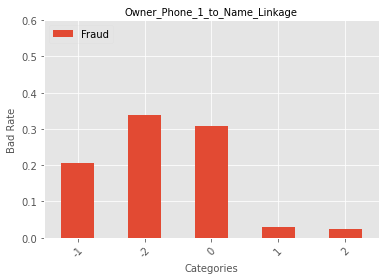

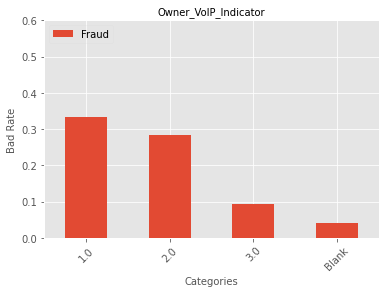

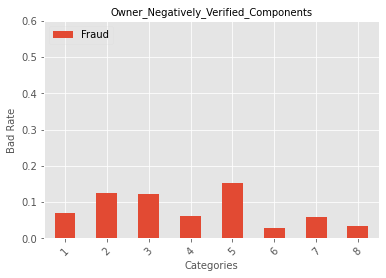

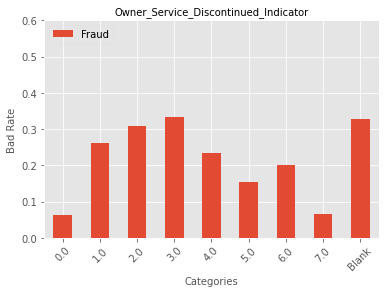

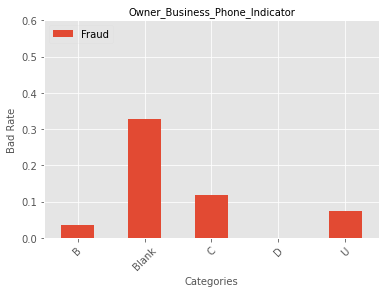

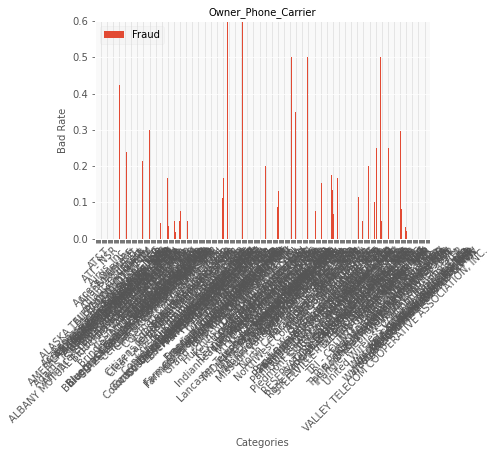

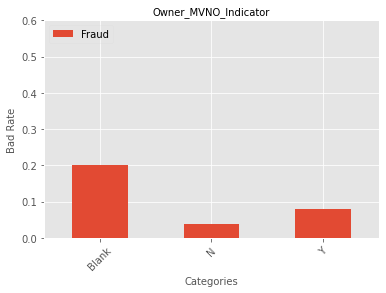

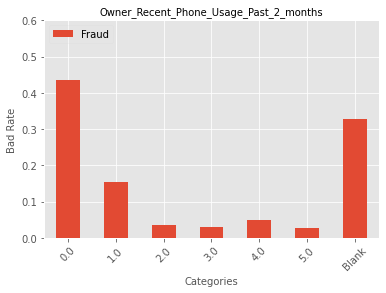

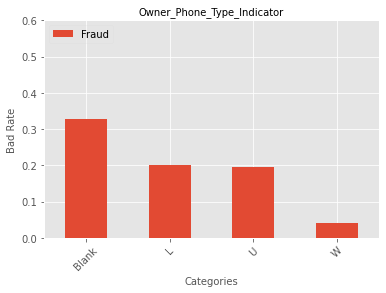

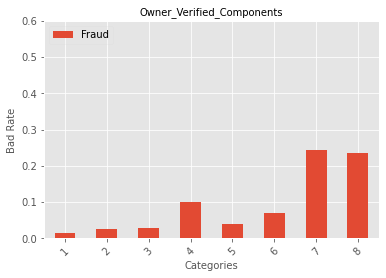

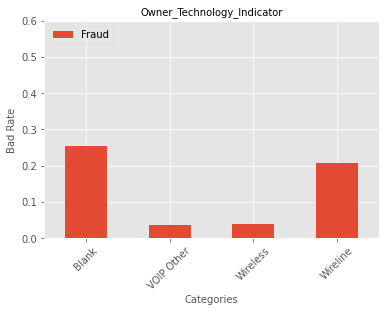

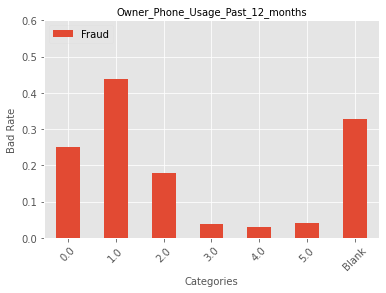

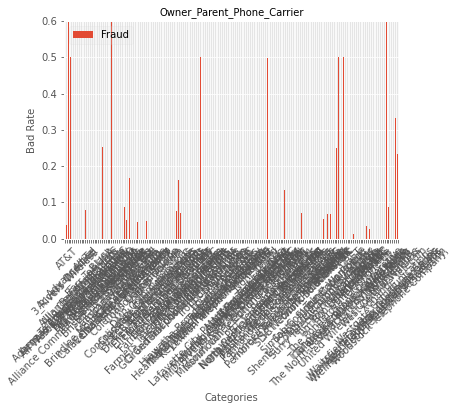

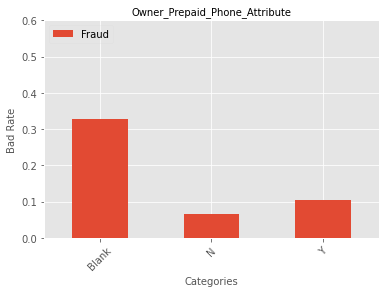

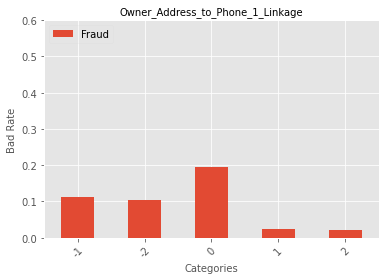

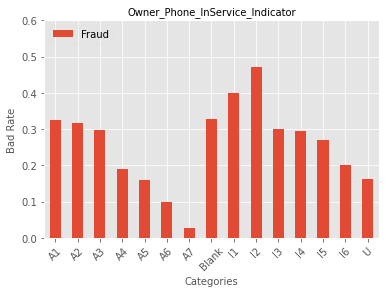

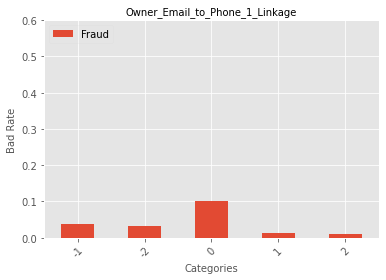

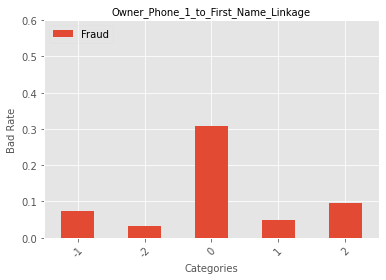

In [71]:
for i in vendor_features:
    df_vendor.groupby(i)["Fraud"].mean().plot(kind= "bar")
    plt.title("{}".format(i), fontsize= 10)
    plt.xticks(fontsize= 10, rotation = 45)
    plt.yticks(fontsize = 10)
    plt.ylim(0, 0.6)
    plt.xlabel("Categories", fontsize = 10)
    plt.ylabel("Bad Rate", fontsize = 10)
    plt.legend(loc= "upper left", framealpha = 0.2)
    plt.show()

In [72]:
df_vendor["PhoneActiveLessthan12Months"] = np.where(df_vendor["Owner_Phone_InService_Indicator"]=="A7", "No", "Yes")
df_vendor["OwnerPhoneNameLinkageWithNoAccuracy"] = np.where(df_vendor["Owner_Phone_1_to_Name_Linkage"].isin(["1", "2"]), "No", "Yes")
df_vendor["OwnerPhoneAddressLinkageWithNoAccuracy"] = np.where(df_vendor["Owner_Address_to_Phone_1_Linkage"].isin(["1", "2"]), "No", "Yes")
df_vendor["RiskyPhoneCarrier"] = np.where(df_vendor["Owner_Phone_Carrier"].isin(["Onvoy - SVR", "NeutralTandem-NSR", "BANDWIDTH.COM"]), "Yes", "No")
df_vendor["NoPhoneUsagePast2Months"] = np.where(df_vendor["Owner_Recent_Phone_Usage_Past_2_months"].isin(["0", "Blank"]), "Yes", "No")
df_vendor["OverTheTopVOIP"] = np.where(df_vendor["Owner_VoIP_Indicator"].isin(["1.0", "2.0"]), "Yes", "No")

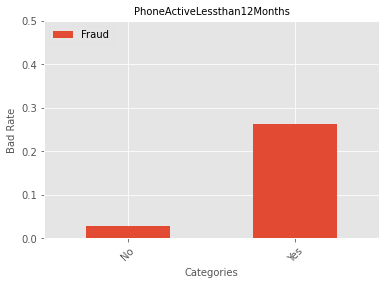

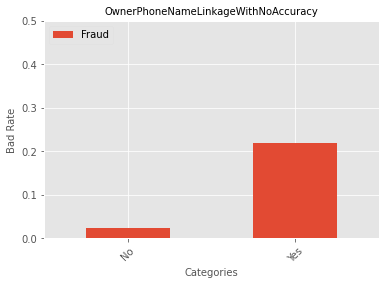

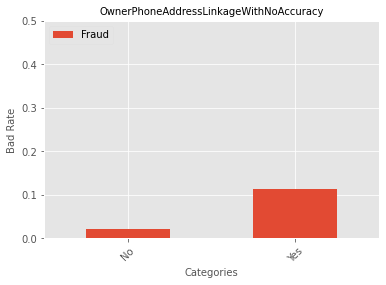

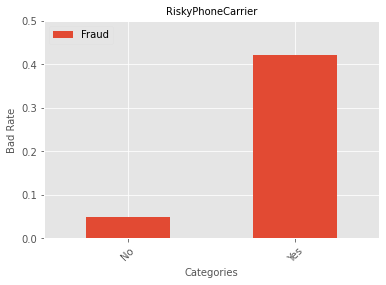

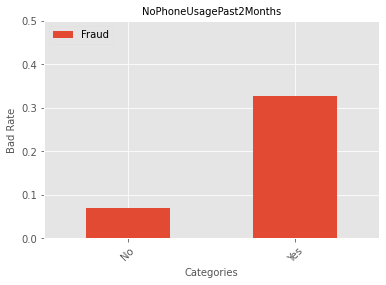

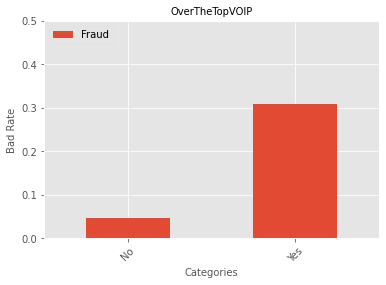

In [73]:
enginered_feat= ["PhoneActiveLessthan12Months", "OwnerPhoneNameLinkageWithNoAccuracy", "OwnerPhoneAddressLinkageWithNoAccuracy",
                "RiskyPhoneCarrier", "NoPhoneUsagePast2Months", "OverTheTopVOIP"]
for i in enginered_feat:
    df_vendor.groupby(i)["Fraud"].mean().plot(kind= "bar")
    plt.title("{}".format(i), fontsize= 10)
    plt.xticks(fontsize= 10, rotation = 45)
    plt.yticks(fontsize = 10)
    plt.ylim(0, 0.5)
    plt.xlabel("Categories", fontsize = 10)
    plt.ylabel("Bad Rate", fontsize = 10)
    plt.legend(loc= "upper left", framealpha = 0.2)
    plt.show()

In [74]:
valid_categories = df_vendor["Owner_Phone_Carrier"].value_counts()
valid_categories = valid_categories[valid_categories > 50].index

In [75]:
valid_categories

Index(['Verizon Wireless - SVR', 'Cingular Wireless', 'T-Mobile US-TSI',
       'Sprint PCS', 'BANDWIDTH.COM', 'Level 3-SVR', 'Comcast Phone',
       'Metro PCS Comm - NSR', 'Blank', 'Time Warner Cable - NSR',
       'USCC - SVR', 'Verizon', 'Frontier Rochester- SVR', 'SBC IP',
       'Charter Fiber - NSR', 'NeutralTandem-NSR', 'Cox Communications',
       'Vonage Network Inc', 'RCLEC- NSR', 'Comcast Phone FL', 'Onvoy - SVR',
       'Pacific Bell - Nevada Bell', 'Qwest_Communications'],
      dtype='object')

In [76]:
df_vendor.loc[df_vendor["Owner_Phone_Carrier"].isin(valid_categories)]["Owner_Phone_Carrier"].value_counts()

Verizon Wireless - SVR        7161
Cingular Wireless             5569
T-Mobile US-TSI               2539
Sprint PCS                    1769
BANDWIDTH.COM                 1039
Level 3-SVR                    286
Comcast Phone                  263
Metro PCS Comm - NSR           253
Blank                          188
Time Warner Cable - NSR        169
USCC - SVR                     142
Verizon                        118
Frontier Rochester- SVR        102
SBC IP                          92
Charter Fiber - NSR             90
NeutralTandem-NSR               86
Cox Communications              82
Vonage Network Inc              60
RCLEC- NSR                      59
Comcast Phone FL                57
Onvoy - SVR                     54
Pacific Bell - Nevada Bell      52
Qwest_Communications            52
Name: Owner_Phone_Carrier, dtype: int64

<AxesSubplot:xlabel='Owner_Phone_Carrier'>

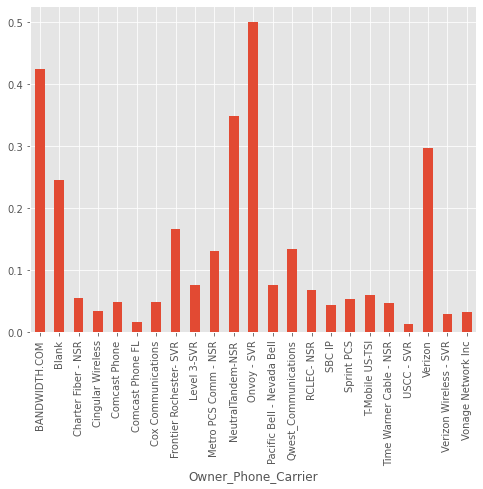

In [77]:
plt.rcParams["figure.figsize"] = (8,6)
df_vendor.loc[df_vendor["Owner_Phone_Carrier"].isin(valid_categories)].groupby("Owner_Phone_Carrier")["Fraud"].mean().plot(kind= "bar")

### Strategy with vendor data

In [78]:
df_vendor.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Owner_MVNO_Indicator,Fraud,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,N,0,"(2.0386, 2.4194]",Approve,No,No,Yes,No,No,No
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,Blank,0,"(1.726, 2.0386]",Approve,No,No,Yes,No,No,Yes
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,N,0,"(0.694, 0.815]",Approve,Yes,Yes,No,No,No,No
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,N,0,"(0.385, 0.483]",Approve,Yes,No,No,No,No,No
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,N,0,"(0.948, 1.107]",Approve,No,No,No,No,No,No


In [84]:
uw_th_approve_v = round(df_vendor["UWScore"].quantile(0.96))
id_th_approve_v = round(df_vendor["IdentityScore"].quantile(0.96))
ea_th_approve_v = round(df_vendor["EAScore"].quantile(0.9999))

In [136]:
uw_th_approve_v, id_th_approve_v

(19, 721)

In [85]:
uw_th_review_v = round(df_vendor["UWScore"].quantile(0.94))
id_th_review_v = round(df_vendor["IdentityScore"].quantile(0.94))
ea_th_review_v = round(df_vendor["EAScore"].quantile(0.99))

In [137]:
uw_th_review_v, id_th_review_v, ea_th_review_v

(14, 683, 904)

In [86]:
enginered_feat

['PhoneActiveLessthan12Months',
 'OwnerPhoneNameLinkageWithNoAccuracy',
 'OwnerPhoneAddressLinkageWithNoAccuracy',
 'RiskyPhoneCarrier',
 'NoPhoneUsagePast2Months',
 'OverTheTopVOIP']

In [91]:
def base_strategy_with_vendor(row, uw_th_approve, id_th_approve, uw_th_review, id_th_review, ea_th_review):
    # List of vendor risk flags
    vendor_flags = [
        'PhoneActiveLessthan12Months',
        'OwnerPhoneNameLinkageWithNoAccuracy',
        'OwnerPhoneAddressLinkageWithNoAccuracy',
        'RiskyPhoneCarrier',
        'NoPhoneUsagePast2Months',
        'OverTheTopVOIP'
    ]
    
    # Count how many vendor flags are marked "Yes"
    vendor_risks = sum([row[flag] == "Yes" for flag in vendor_flags])

    # Decline if any score exceeds approval thresholds
    if (
        row['UWScore'] >= uw_th_approve or
        row['IdentityScore'] >= id_th_approve
    ):
        return 'Decline'

    # Manual review if any score in review band OR ≥ 3 vendor risks
    elif (
        (uw_th_review <= row["UWScore"] < uw_th_approve) or
        ((id_th_review <= row["IdentityScore"] < id_th_approve) if pd.notnull(row["IdentityScore"]) else True) or
        ((ea_th_review <= row["EAScore"]) if pd.notnull(row["EAScore"]) else True) or
        (vendor_risks >= 4)
    ):
        return 'ManualReview'

    # Otherwise, approve
    else:
        return 'Approve'

In [92]:
df_vendor['DecisionWithVendor'] = df_vendor.apply(
    lambda row: base_strategy_with_vendor(
        row,
        uw_th_approve_v,
        id_th_approve_v,
#         ea_th_approve_v,
        uw_th_review_v,
        id_th_review_v,
        ea_th_review_v
    ),
    axis=1
)

In [93]:
df_strategy_vendor= strategy(df_vendor, "DecisionWithVendor")

In [94]:
df_strategy_vendor

,Decision,AppCount,FraudCount,FraudRate,DecisionRate,FraudCaptureRate
0,Approve,17521,484,0.0276,0.8150,0.3233
1,Decline,1290,549,0.4256,0.0600,0.3667
2,ManualReview,2686,464,0.1727,0.1249,0.3100


In [95]:
df_strategy

,Decision,AppCount,FraudCount,FraudRate,DecisionRate,FraudCaptureRate
0,Approve,17979,675,0.0375,0.8363,0.4509
1,Decline,1605,630,0.3925,0.0747,0.4208
2,ManualReview,1913,192,0.1004,0.0890,0.1283


In [96]:
out_vendor = ROI_calc (df_strategy_vendor, "DecisionWithVendor", vendor= "Yes")

In [97]:
out_vendor

,Metrics,Value
0,TotalApps,21497.0000
1,ApprovedApps,17521.0000
2,FraudAppsApproved,484.0000
3,LegitApprovedApps,17037.0000
4,RevenurApprovedApps,8177760.0000
5,FraudLossApprovedApps,242000.0000
6,ManualReviewApps,2686.0000
7,FraudAppsManualReview,464.0000
8,LegitManualReviewApps,2222.0000
9,LegitManualReviewApprovedApps,667.0000


## With Model from Vendor Data

In [98]:
df_vendor.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Fraud,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor
0,1000001,550.0000,81.0000,2.1670,5,6,2,-1,-2,-1,...,0,"(2.0386, 2.4194]",Approve,No,No,Yes,No,No,No,Approve
1,1000002,539.0000,98.0000,1.7300,2,6,1,1,-1,-1,...,0,"(1.726, 2.0386]",Approve,No,No,Yes,No,No,Yes,Approve
2,1000003,361.0000,500.0000,0.7440,7,5,-1,2,2,0,...,0,"(0.694, 0.815]",Approve,Yes,Yes,No,No,No,No,Approve
3,1000004,442.0000,119.0000,0.4050,2,8,2,1,2,0,...,0,"(0.385, 0.483]",Approve,Yes,No,No,No,No,No,Approve
4,1000005,431.0000,82.0000,1.0630,1,8,2,1,2,2,...,0,"(0.948, 1.107]",Approve,No,No,No,No,No,No,Approve


In [99]:
# Assume df is your original DataFrame
df_model = df_vendor.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle the data

n = len(df_model)
split1 = int(0.50 * n)
split2 = int(0.45 * n) + split1  # 45% + 5% = 50%

# Split the data
df_train = df_model.iloc[:split1]
df_validation  = df_model.iloc[split1:split2]
df_test = df_model.iloc[split2:]

In [100]:
df_train.shape[0]/df_model.shape[0], df_validation.shape[0]/df_model.shape[0], df_test.shape[0]/df_model.shape[0]

(0.49997674094059635, 0.44996976322277527, 0.05005349583662837)

In [101]:
df_train.shape, df_validation.shape

((10748, 32), (9673, 32))

In [102]:
df_train.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Fraud,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor
0,1014145,337.0000,235.0000,0.3260,2,5,2,-2,1,-2,...,0,"(0.272, 0.385]",Approve,No,No,No,No,No,No,Approve
1,1017549,538.0000,254.0000,1.7320,7,3,-1,2,-1,0,...,0,"(1.726, 2.0386]",Approve,Yes,Yes,Yes,Yes,No,Yes,ManualReview
2,1013905,535.0000,84.0000,14.2860,1,8,2,-1,2,1,...,0,"(9.1244, 16.2976]",ManualReview,No,No,No,No,No,No,ManualReview
3,1016237,759.0000,183.0000,7.3990,8,8,0,0,0,0,...,0,"(6.241, 9.1244]",Decline,Yes,Yes,Yes,No,No,No,Decline
4,1017355,575.0000,77.0000,5.6670,6,5,-1,2,-1,-1,...,0,"(4.637, 6.241]",Approve,Yes,Yes,Yes,No,No,Yes,ManualReview


In [103]:
vendor_features

['Owner_Phone_1_to_Name_Linkage',
 'Owner_VoIP_Indicator',
 'Owner_Negatively_Verified_Components',
 'Owner_Service_Discontinued_Indicator',
 'Owner_Business_Phone_Indicator',
 'Owner_Phone_Carrier',
 'Owner_MVNO_Indicator',
 'Owner_Recent_Phone_Usage_Past_2_months',
 'Owner_Phone_Type_Indicator',
 'Owner_Verified_Components',
 'Owner_Technology_Indicator',
 'Owner_Phone_Usage_Past_12_months',
 'Owner_Parent_Phone_Carrier',
 'Owner_Prepaid_Phone_Attribute',
 'Owner_Address_to_Phone_1_Linkage',
 'Owner_Phone_InService_Indicator',
 'Owner_Email_to_Phone_1_Linkage',
 'Owner_Phone_1_to_First_Name_Linkage']

In [104]:
encoder = ce.WOEEncoder(cols=vendor_features)
encoder.fit(df_train, df_train['Fraud'])

df_train_encoded = encoder.transform(df_train)
df_test_encoded = encoder.transform(df_test)
df_validation_encoded = encoder.transform(df_validation)

In [105]:
df_train_encoded.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Fraud,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor
0,1014145,337.0000,235.0000,0.3260,-1.0110,0.8220,-1.1051,-0.8113,-1.0361,-0.7222,...,0,"(0.272, 0.385]",Approve,No,No,No,No,No,No,Approve
1,1017549,538.0000,254.0000,1.7320,1.4126,0.5836,1.1888,0.3748,0.4994,0.3849,...,0,"(1.726, 2.0386]",Approve,Yes,Yes,Yes,Yes,No,Yes,ManualReview
2,1013905,535.0000,84.0000,14.2860,-1.5410,-0.7140,-1.1051,0.0250,-1.1651,-1.4402,...,0,"(9.1244, 16.2976]",ManualReview,No,No,No,No,No,No,ManualReview
3,1016237,759.0000,183.0000,7.3990,1.4888,-0.7140,1.8798,1.8798,1.2245,0.3849,...,0,"(6.241, 9.1244]",Decline,Yes,Yes,Yes,No,No,No,Decline
4,1017355,575.0000,77.0000,5.6670,-0.0553,0.8220,1.1888,0.3748,0.4994,-0.5841,...,0,"(4.637, 6.241]",Approve,Yes,Yes,Yes,No,No,Yes,ManualReview


In [106]:
def fit_xgb_model (train, test, predictors, target, seed):
    """
    This function fits a baseline xgboost algorithms with given parameters and returns a model object
    """

    x_train= train[predictors]
    x_test= test[predictors]
    y_train= train[target]
    y_test= test[target]

    params= {'booster': 'gbtree',
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'process_type': 'default',
            'eta': 0.4,
            'grow_policy': 'lossguide',
            'tree_method': 'hist',
            'max_depth': 6,
            'max_leaves': 0,
            'min_child_weight': 150,
            'max_delta_step': 0,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'colsample_bylevel': 1,
            'colsample_bynode': 1,
            'gamma': 0,
            'lambda': 1,
            'alpha': 0,
            'scale_pos_weight': 1,
            'max_bin': 256,
            'num_parallel_tree': 1,
            'random_state': seed,
#             'monotone_constraints': monotonity,
            'n_estimators': 400 
    }

    model = xgb.XGBClassifier(verbose = True, **params)

    evaluation= [(x_train, y_train), (x_test, y_test)]

    model= model.fit(x_train, y_train, eval_set= evaluation,
                    early_stopping_rounds = 20
                    )

    return model

In [107]:
model = fit_xgb_model(df_train_encoded, df_test_encoded, vendor_features, target= "Fraud", seed=42)

[0]	validation_0-auc:0.797731	validation_1-auc:0.79956
Multiple eval metrics have been passed: 'validation_1-auc' will be used for early stopping.

Will train until validation_1-auc hasn't improved in 20 rounds.
[1]	validation_0-auc:0.810133	validation_1-auc:0.808636
[2]	validation_0-auc:0.808905	validation_1-auc:0.806676
[3]	validation_0-auc:0.810406	validation_1-auc:0.80895
[4]	validation_0-auc:0.818564	validation_1-auc:0.815724
[5]	validation_0-auc:0.825005	validation_1-auc:0.825025
[6]	validation_0-auc:0.823896	validation_1-auc:0.823666
[7]	validation_0-auc:0.827903	validation_1-auc:0.82859
[8]	validation_0-auc:0.830712	validation_1-auc:0.834899
[9]	validation_0-auc:0.830075	validation_1-auc:0.838075
[10]	validation_0-auc:0.830476	validation_1-auc:0.839345
[11]	validation_0-auc:0.830907	validation_1-auc:0.838239
[12]	validation_0-auc:0.830403	validation_1-auc:0.838771
[13]	validation_0-auc:0.831374	validation_1-auc:0.84056
[14]	validation_0-auc:0.833729	validation_1-auc:0.842862
[1

In [108]:
# Predict probabilities (you can also use .predict() for 0/1)
df_train_encoded['pred_prob'] = model.predict_proba(df_train_encoded[vendor_features])[:, 1]
df_test_encoded['pred_prob'] = model.predict_proba(df_test_encoded[vendor_features])[:, 1]
df_validation_encoded['pred_prob'] = model.predict_proba(df_validation_encoded[vendor_features])[:, 1]

In [109]:
df_validation_encoded.head(5)

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor,pred_prob
10748,1013112,485.0000,500.0000,1.8920,-0.6289,-0.1368,-1.1051,-0.3970,0.4994,-0.7222,...,"(1.726, 2.0386]",Approve,No,No,Yes,No,No,No,Approve,0.0651
10749,1006145,357.0000,73.0000,0.5420,-1.5410,-0.7140,-1.1051,0.3748,-1.0361,-1.4402,...,"(0.483, 0.586]",Approve,No,No,No,No,No,No,Approve,0.0582
10750,1000647,477.0000,500.0000,7.4030,1.4126,0.8220,1.1888,0.0250,0.4994,0.3849,...,"(6.241, 9.1244]",Approve,No,Yes,Yes,No,No,No,Approve,0.1418
10751,1018741,406.0000,197.0000,0.6680,-1.0110,-0.7536,-0.7315,-0.3970,0.4994,-0.5841,...,"(0.586, 0.694]",Approve,No,No,Yes,No,No,No,Approve,0.0676
10752,1013556,462.0000,500.0000,1.5930,1.4126,-0.7140,1.8798,1.8798,0.4994,-0.7222,...,"(1.485, 1.726]",Approve,No,Yes,Yes,No,No,No,Approve,0.1255


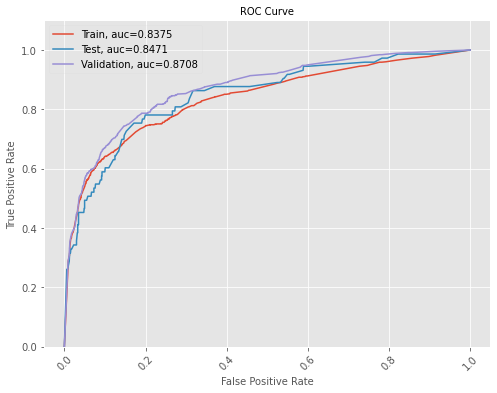

In [110]:
temp = df_train_encoded.loc[df_train_encoded["pred_prob"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["pred_prob"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["pred_prob"]), 4)
plt.plot(fpr, tpr, label= "Train, auc={}".format(str(auc)))

temp = df_test_encoded.loc[df_test_encoded["pred_prob"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["pred_prob"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["pred_prob"]), 4)
plt.plot(fpr, tpr, label= "Test, auc={}".format(str(auc)))

temp = df_validation_encoded.loc[df_validation_encoded["pred_prob"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["pred_prob"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["pred_prob"]), 4)
plt.plot(fpr, tpr, label= "Validation, auc={}".format(str(auc)))


plt.title("ROC Curve", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 1.1)
plt.xlabel("False Positive Rate", fontsize = 10)
plt.ylabel("True Positive Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

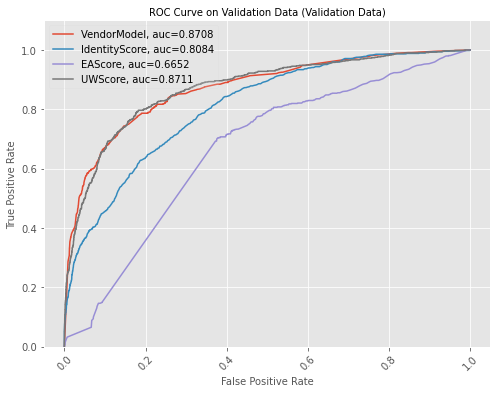

In [111]:
temp = df_validation_encoded.loc[df_validation_encoded["pred_prob"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["pred_prob"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["pred_prob"]), 4)
plt.plot(fpr, tpr, label= "VendorModel, auc={}".format(str(auc)))

temp = df_validation_encoded.loc[df_validation_encoded["IdentityScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["IdentityScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["IdentityScore"]), 4)
plt.plot(fpr, tpr, label= "IdentityScore, auc={}".format(str(auc)))

temp = df_validation_encoded.loc[df_validation_encoded["EAScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["EAScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["EAScore"]), 4)
plt.plot(fpr, tpr, label= "EAScore, auc={}".format(str(auc)))

temp = df_validation_encoded.loc[df_validation_encoded["UWScore"].notnull()]
fpr, tpr, _ = metrics.roc_curve(temp["Fraud"], temp["UWScore"])
auc = round(metrics.roc_auc_score(temp["Fraud"], temp["UWScore"]), 4)
plt.plot(fpr, tpr, label= "UWScore, auc={}".format(str(auc)))


plt.title("ROC Curve on Validation Data (Validation Data)", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 1.1)
plt.xlabel("False Positive Rate", fontsize = 10)
plt.ylabel("True Positive Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

In [112]:
df_id_val = bad_capture_rate(df_validation_encoded, "Fraud", "IdentityScore", 20)
df_ea_val = bad_capture_rate(df_validation_encoded, "Fraud", "EAScore", 20)
df_uw_val = bad_capture_rate(df_validation_encoded, "Fraud", "UWScore", 20)
df_model_val = bad_capture_rate(df_validation_encoded, "Fraud", "pred_prob", 20)

In [141]:
df_model_val

,cut_base_pred_prob,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(0.331018, 0.45986]",483,274,209,0.5673,483,274,0.5673,0.3948,0.3948,0.0499
1,"(0.199625, 0.331018]",483,137,346,0.2836,966,411,0.4255,0.1974,0.5922,0.0999
2,"(0.141876, 0.199625]",485,62,423,0.1278,1451,473,0.3260,0.0893,0.6816,0.1500
3,"(0.12786, 0.141876]",460,47,413,0.1022,1911,520,0.2721,0.0677,0.7493,0.1976
4,"(0.121705, 0.12786]",494,28,466,0.0567,2405,548,0.2279,0.0403,0.7896,0.2486
5,"(0.0864579, 0.121705]",497,34,463,0.0684,2902,582,0.2006,0.0490,0.8386,0.3000
6,"(0.0739111, 0.0864579]",375,10,365,0.0267,3277,592,0.1807,0.0144,0.8530,0.3388
7,"(0.0712368, 0.0739111]",455,16,439,0.0352,3732,608,0.1629,0.0231,0.8761,0.3858
8,"(0.0662073, 0.0712368]",601,15,586,0.0250,4333,623,0.1438,0.0216,0.8977,0.4479
9,"(0.0650663, 0.0662073]",426,11,415,0.0258,4759,634,0.1332,0.0159,0.9135,0.4920


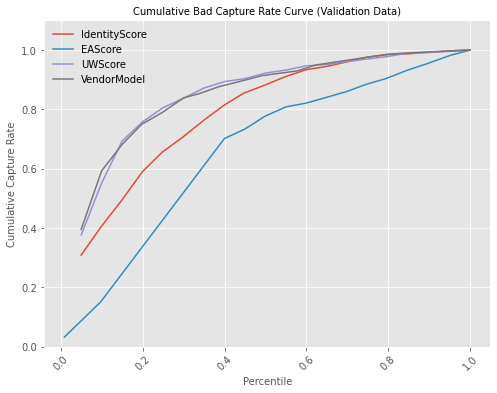

In [113]:
plt.plot(df_id_val["precentile"], df_id_val["bad_capture_rate_cumulative_bin"], label= "IdentityScore")
plt.plot(df_ea_val["precentile"], df_ea_val["bad_capture_rate_cumulative_bin"], label= "EAScore")
plt.plot(df_uw_val["precentile"], df_uw_val["bad_capture_rate_cumulative_bin"], label= "UWScore")
plt.plot(df_model_val["precentile"], df_model_val["bad_capture_rate_cumulative_bin"], label= "VendorModel")

plt.title("Cumulative Bad Capture Rate Curve (Validation Data)", fontsize= 10)
plt.xticks(fontsize= 10, rotation = 45)
plt.yticks(fontsize = 10)
plt.ylim(0, 1.1)
plt.xlabel("Percentile", fontsize = 10)
plt.ylabel("Cumulative Capture Rate", fontsize = 10)
plt.legend(loc= "upper left", framealpha = 0.2)
plt.show()

In [114]:
# Get raw feature importance
importance_dict = model.get_booster().get_score(importance_type='gain')  # or 'weight', 'cover'

# Convert to DataFrame
importance_df = pd.DataFrame.from_dict(importance_dict, orient='index', columns=['Importance'])
importance_df.index.name = 'Feature'
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index()

In [115]:
importance_df

,Feature,Importance
0,Owner_Phone_InService_Indicator,108.7345
1,Owner_Phone_Usage_Past_12_months,79.4147
2,Owner_Recent_Phone_Usage_Past_2_months,77.1601
3,Owner_Verified_Components,72.8459
4,Owner_Phone_Carrier,66.2630
5,Owner_Phone_1_to_Name_Linkage,31.8442
6,Owner_Parent_Phone_Carrier,11.2726
7,Owner_Email_to_Phone_1_Linkage,10.3137
8,Owner_Address_to_Phone_1_Linkage,4.9139
9,Owner_Negatively_Verified_Components,3.0491


In [117]:
importance_df["Importance_%"] = importance_df["Importance"]*100/importance_df["Importance"].sum()

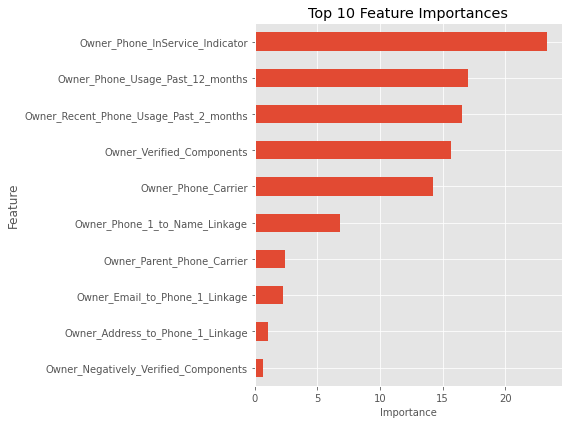

In [119]:
importance_df.head(10).plot(kind='barh', y='Importance_%', x='Feature', legend=False)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance", fontsize = 10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [120]:
df_model_val.head()

,cut_base_pred_prob,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(0.331018, 0.45986]",483,274,209,0.5673,483,274,0.5673,0.3948,0.3948,0.0499
1,"(0.199625, 0.331018]",483,137,346,0.2836,966,411,0.4255,0.1974,0.5922,0.0999
2,"(0.141876, 0.199625]",485,62,423,0.1278,1451,473,0.3260,0.0893,0.6816,0.1500
3,"(0.12786, 0.141876]",460,47,413,0.1022,1911,520,0.2721,0.0677,0.7493,0.1976
4,"(0.121705, 0.12786]",494,28,466,0.0567,2405,548,0.2279,0.0403,0.7896,0.2486


In [121]:
df_uw_val.head()

,cut_base_UWScore,base_total_count,base_bad_count,base_good_count,bad_rate,cumulative_total,cumulative_bad,cumulative_precision,bad_capture_rate_bin,bad_capture_rate_cumulative_bin,precentile
0,"(16.104, 98.822]",484,261,223,0.5393,484,261,0.5393,0.3761,0.3761,0.0500
1,"(9.233, 16.104]",484,122,362,0.2521,968,383,0.3957,0.1758,0.5519,0.1001
2,"(6.3952, 9.233]",483,98,385,0.2029,1451,481,0.3315,0.1412,0.6931,0.1500
3,"(4.7236, 6.3952]",484,45,439,0.0930,1935,526,0.2718,0.0648,0.7579,0.2000
4,"(3.691, 4.7236]",482,33,449,0.0685,2417,559,0.2313,0.0476,0.8055,0.2499


In [122]:
df_validation_encoded.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,cut_base,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor,pred_prob
10748,1013112,485.0000,500.0000,1.8920,-0.6289,-0.1368,-1.1051,-0.3970,0.4994,-0.7222,...,"(0.0637926, 0.0650663]",Approve,No,No,Yes,No,No,No,Approve,0.0651
10749,1006145,357.0000,73.0000,0.5420,-1.5410,-0.7140,-1.1051,0.3748,-1.0361,-1.4402,...,"(0.0581961, 0.0592178]",Approve,No,No,No,No,No,No,Approve,0.0582
10750,1000647,477.0000,500.0000,7.4030,1.4126,0.8220,1.1888,0.0250,0.4994,0.3849,...,"(0.12786, 0.141876]",Approve,No,Yes,Yes,No,No,No,Approve,0.1418
10751,1018741,406.0000,197.0000,0.6680,-1.0110,-0.7536,-0.7315,-0.3970,0.4994,-0.5841,...,"(0.0662073, 0.0712368]",Approve,No,No,Yes,No,No,No,Approve,0.0676
10752,1013556,462.0000,500.0000,1.5930,1.4126,-0.7140,1.8798,1.8798,0.4994,-0.7222,...,"(0.121705, 0.12786]",Approve,No,Yes,Yes,No,No,No,Approve,0.1255


In [123]:
uw_th_approve_vm = round(df_validation_encoded["UWScore"].quantile(0.96))
id_th_approve_vm = round(df_validation_encoded["IdentityScore"].quantile(0.96))
model_th_approve_vm = round(df_validation_encoded["pred_prob"].quantile(0.96), 4)

In [138]:
uw_th_approve_vm, id_th_approve_vm, model_th_approve_vm

(19, 723, 0.3843)

In [139]:
uw_th_review_vm = round(df_vendor["UWScore"].quantile(0.94))
id_th_review_vm = round(df_vendor["IdentityScore"].quantile(0.94))
ea_th_review_vm = round(df_vendor["EAScore"].quantile(0.99))
model_th_review_vm = round(df_validation_encoded["pred_prob"].quantile(0.94),4)

In [140]:
uw_th_review_vm, id_th_review_vm, ea_th_review_vm, model_th_review_vm

(14, 683, 904, 0.3183)

In [125]:
def base_strategy_with_vendormodel(row, uw_th_approve, id_th_approve, model_th_approve, uw_th_review, id_th_review, ea_th_review, model_th_review):
    

    # Decline if any score exceeds approval thresholds
    if (
        row['UWScore'] >= uw_th_approve or
        row['IdentityScore'] >= id_th_approve or
        row['pred_prob'] >= model_th_approve
    ):
        return 'Decline'

    # Manual review if any score in review band OR ≥ 3 vendor risks
    elif (
        (uw_th_review <= row["UWScore"] < uw_th_approve) or
        ((id_th_review <= row["IdentityScore"] < id_th_approve) if pd.notnull(row["IdentityScore"]) else True) or
        ((ea_th_review <= row["EAScore"]) if pd.notnull(row["EAScore"]) else True) or
        (model_th_review <= row["pred_prob"] < model_th_approve)
    ):
        return 'ManualReview'

    # Otherwise, approve
    else:
        return 'Approve'

In [126]:
df_validation_encoded['DecisionWithVendorModel'] = df_validation_encoded.apply(
    lambda row: base_strategy_with_vendormodel(
        row,
        uw_th_approve_vm,
        id_th_approve_vm,
        model_th_approve_vm,
        uw_th_review_vm,
        id_th_review_vm,
        ea_th_review_vm,
        model_th_review_vm
    ),
    axis=1
)

In [127]:
uw_th_approve_vm, id_th_approve_vm, model_th_approve_vm

(19, 723, 0.3843)

In [128]:
df_validation_encoded.head()

,Identifier,IdentityScore,EAScore,UWScore,Owner_Verified_Components,Owner_Negatively_Verified_Components,Owner_Phone_1_to_Name_Linkage,Owner_Phone_1_to_First_Name_Linkage,Owner_Address_to_Phone_1_Linkage,Owner_Email_to_Phone_1_Linkage,...,Decision,PhoneActiveLessthan12Months,OwnerPhoneNameLinkageWithNoAccuracy,OwnerPhoneAddressLinkageWithNoAccuracy,RiskyPhoneCarrier,NoPhoneUsagePast2Months,OverTheTopVOIP,DecisionWithVendor,pred_prob,DecisionWithVendorModel
10748,1013112,485.0000,500.0000,1.8920,-0.6289,-0.1368,-1.1051,-0.3970,0.4994,-0.7222,...,Approve,No,No,Yes,No,No,No,Approve,0.0651,Approve
10749,1006145,357.0000,73.0000,0.5420,-1.5410,-0.7140,-1.1051,0.3748,-1.0361,-1.4402,...,Approve,No,No,No,No,No,No,Approve,0.0582,Approve
10750,1000647,477.0000,500.0000,7.4030,1.4126,0.8220,1.1888,0.0250,0.4994,0.3849,...,Approve,No,Yes,Yes,No,No,No,Approve,0.1418,Approve
10751,1018741,406.0000,197.0000,0.6680,-1.0110,-0.7536,-0.7315,-0.3970,0.4994,-0.5841,...,Approve,No,No,Yes,No,No,No,Approve,0.0676,Approve
10752,1013556,462.0000,500.0000,1.5930,1.4126,-0.7140,1.8798,1.8798,0.4994,-0.7222,...,Approve,No,Yes,Yes,No,No,No,Approve,0.1255,Approve


In [129]:
df_strategy_vendormodel= strategy(df_validation_encoded, "DecisionWithVendorModel")

In [130]:
df_strategy_vendormodel

,Decision,AppCount,FraudCount,FraudRate,DecisionRate,FraudCaptureRate
0,Approve,7875,193,0.0245,0.8141,0.2781
1,Decline,847,416,0.4911,0.0876,0.5994
2,ManualReview,951,85,0.0894,0.0983,0.1225


In [131]:
out_vendor_model = ROI_calc (df_strategy_vendormodel, "DecisionWithVendorModel", vendor= "Yes")

In [132]:
out_vendor_model

,Metrics,Value
0,TotalApps,9673.0000
1,ApprovedApps,7875.0000
2,FraudAppsApproved,193.0000
3,LegitApprovedApps,7682.0000
4,RevenurApprovedApps,3687360.0000
5,FraudLossApprovedApps,96500.0000
6,ManualReviewApps,951.0000
7,FraudAppsManualReview,85.0000
8,LegitManualReviewApps,866.0000
9,LegitManualReviewApprovedApps,260.0000


# Assumptions
- Apps and amounts are rounded to nearest integers
- Data is of approved apps (passed the underwriting decisioning)
- Fraud labels are on the approved apps based on their later performance
- Fraud rates are consistent throughout the year
- App volume and approval rate is consistent throughout the year
- Manual review eliminates all the fraud cases

# Summary

In [133]:
out

,Metrics,Value
0,TotalApps,21497.0000
1,ApprovedApps,17979.0000
2,FraudAppsApproved,675.0000
3,LegitApprovedApps,17304.0000
4,RevenurApprovedApps,8305920.0000
5,FraudLossApprovedApps,337500.0000
6,ManualReviewApps,1913.0000
7,FraudAppsManualReview,192.0000
8,LegitManualReviewApps,1721.0000
9,LegitManualReviewApprovedApps,516.0000


In [134]:
out_vendor

,Metrics,Value
0,TotalApps,21497.0000
1,ApprovedApps,17521.0000
2,FraudAppsApproved,484.0000
3,LegitApprovedApps,17037.0000
4,RevenurApprovedApps,8177760.0000
5,FraudLossApprovedApps,242000.0000
6,ManualReviewApps,2686.0000
7,FraudAppsManualReview,464.0000
8,LegitManualReviewApps,2222.0000
9,LegitManualReviewApprovedApps,667.0000


In [135]:
out_vendor_model

,Metrics,Value
0,TotalApps,9673.0000
1,ApprovedApps,7875.0000
2,FraudAppsApproved,193.0000
3,LegitApprovedApps,7682.0000
4,RevenurApprovedApps,3687360.0000
5,FraudLossApprovedApps,96500.0000
6,ManualReviewApps,951.0000
7,FraudAppsManualReview,85.0000
8,LegitManualReviewApps,866.0000
9,LegitManualReviewApprovedApps,260.0000
